# 00 - Exploratory Data Analysis  
Reusable EDA notebook for any time series dataset.  
Load via CSV file path or database connection (configure in .env or Section 1 below).

## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dotenv import load_dotenv
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

load_dotenv()
DATA_PATH = os.getenv('DATA_PATH')
print(DATA_PATH)
print("Libraries loaded.")

Q:\scripts\projects\ts-model-framework\data
Libraries loaded.


---
## S1 - Data Source Configuration
Set your data source below. Use either CSV or database connection.
Comment/uncomment the relevant block.

In [2]:
# ── CSV SOURCE ──────────────────────────────────────────────
DATA_PATH = os.getenv('DATA_PATH')        # set in .env, or override below
# DATA_PATH = r"Q:\scripts\projects\ts-model-framework\data"  # manual override

FILE_NAME = "timeseries_with_features.csv"   # change as needed
DATE_COLUMN = "date"                          # change to match your dataset
TARGET_COLUMN = "unit_sales"                  # change to match your dataset

# ── DATABASE SOURCE (comment out CSV block above if using this) ──
# DB_URL = os.getenv('MLFLOW_DB_URL')              # set in .env
# DB_QUERY = "SELECT * FROM your_table"
# engine = create_engine(DB_URL)
# df = pd.read_sql(DB_QUERY, engine)

# ── LOAD CSV ─────────────────────────────────────────────────
file_path = os.path.join(DATA_PATH, FILE_NAME)
df = pd.read_csv(file_path, parse_dates=[DATE_COLUMN], index_col=DATE_COLUMN)

print(f"Loaded: {file_path}")
print(f"Shape: {df.shape}")

Loaded: Q:\scripts\projects\ts-model-framework\data\timeseries_with_features.csv
Shape: (452, 24)


---
## S2 - Structure & Data Types

In [3]:
print("Shape:", df.shape)
print()
print("Date range:", df.index.min(), "to", df.index.max())
print()
print("Data types:")
print(df.dtypes)

Shape: (452, 24)

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00

Data types:
unit_sales             float64
dcoilwtico             float64
is_national_holiday      int64
is_regional_holiday      int64
is_local_holiday         int64
year                     int64
month                    int64
day                      int64
dayofweek                int64
quarter                  int64
week_of_year             int64
is_weekend               int64
is_month_start           int64
is_month_end             int64
lag_1                  float64
lag_7                  float64
lag_14                 float64
lag_30                 float64
rolling_7d_mean        float64
rolling_14d_mean       float64
rolling_30d_mean       float64
rolling_7d_std         float64
oil_lag_1              float64
oil_rolling_7d_mean    float64
dtype: object


---
## S3 - Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query("missing_count > 0")

if missing_summary.empty:
    print("No missing values found.")
else:
    print(missing_summary)

                     missing_count  missing_pct
lag_1                            1         0.22
lag_7                            7         1.55
lag_14                          14         3.10
lag_30                          30         6.64
rolling_7d_mean                  7         1.55
rolling_14d_mean                14         3.10
rolling_30d_mean                30         6.64
rolling_7d_std                   7         1.55
oil_lag_1                        1         0.22
oil_rolling_7d_mean              7         1.55


---
## S4 - Basic Statistics

In [5]:
df.describe().round(2)

,unit_sales,dcoilwtico,is_national_holiday,is_regional_holiday,is_local_holiday,year,month,day,dayofweek,quarter,...,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_rolling_7d_mean
count,452.00,452.00,452.00,452.00,452.00,452.0,452.00,452.00,452.00,452.00,...,451.00,445.00,438.00,422.00,445.00,438.00,422.00,445.00,451.00,445.00
mean,480.09,98.14,0.05,0.01,0.05,2013.2,5.64,15.73,3.01,2.21,...,480.24,480.15,481.35,482.19,479.64,478.90,478.82,166.58,98.13,98.14
std,170.84,5.15,0.22,0.09,0.22,0.4,3.59,8.75,2.01,1.17,...,171.00,171.65,171.78,172.51,53.75,38.63,27.50,54.28,5.16,5.07
min,4.00,86.65,0.00,0.00,0.00,2013.0,1.00,1.00,0.00,1.00,...,4.00,4.00,4.00,4.00,341.71,361.71,405.67,63.79,86.65,88.12
25%,358.00,93.96,0.00,0.00,0.00,2013.0,2.00,8.00,1.00,1.00,...,358.00,358.00,358.50,358.50,448.00,454.18,463.71,127.65,93.96,94.19
50%,445.50,97.00,0.00,0.00,0.00,2013.0,5.00,16.00,3.00,2.00,...,447.00,447.00,448.00,451.00,478.14,475.25,475.42,162.70,96.99,96.79
75%,578.25,102.36,0.00,0.00,0.00,2013.0,9.00,23.00,5.00,3.00,...,579.50,577.00,580.75,582.75,506.86,502.82,492.23,196.25,102.36,102.59
max,1203.00,110.62,1.00,1.00,1.00,2014.0,12.00,31.00,6.00,4.00,...,1203.00,1203.00,1203.00,1203.00,661.00,603.93,561.20,395.60,110.62,109.28


---
## S5 - Target Variable Plot

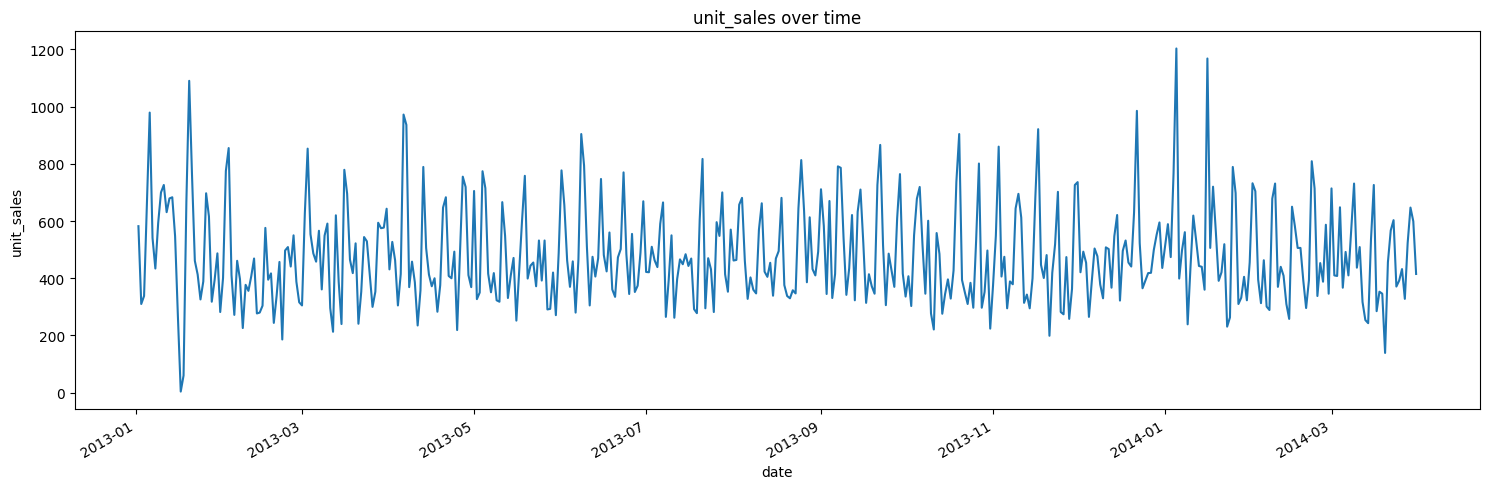

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
df[TARGET_COLUMN].plot(ax=ax)
ax.set_title(f'{TARGET_COLUMN} over time')
ax.set_ylabel(TARGET_COLUMN)
plt.tight_layout()
plt.show()

---
## S6 - Seasonal Decomposition
Splits the target into trend, seasonality, and residual components.
Adjust `period` to match your data frequency (7=weekly, 12=monthly, 365=yearly).

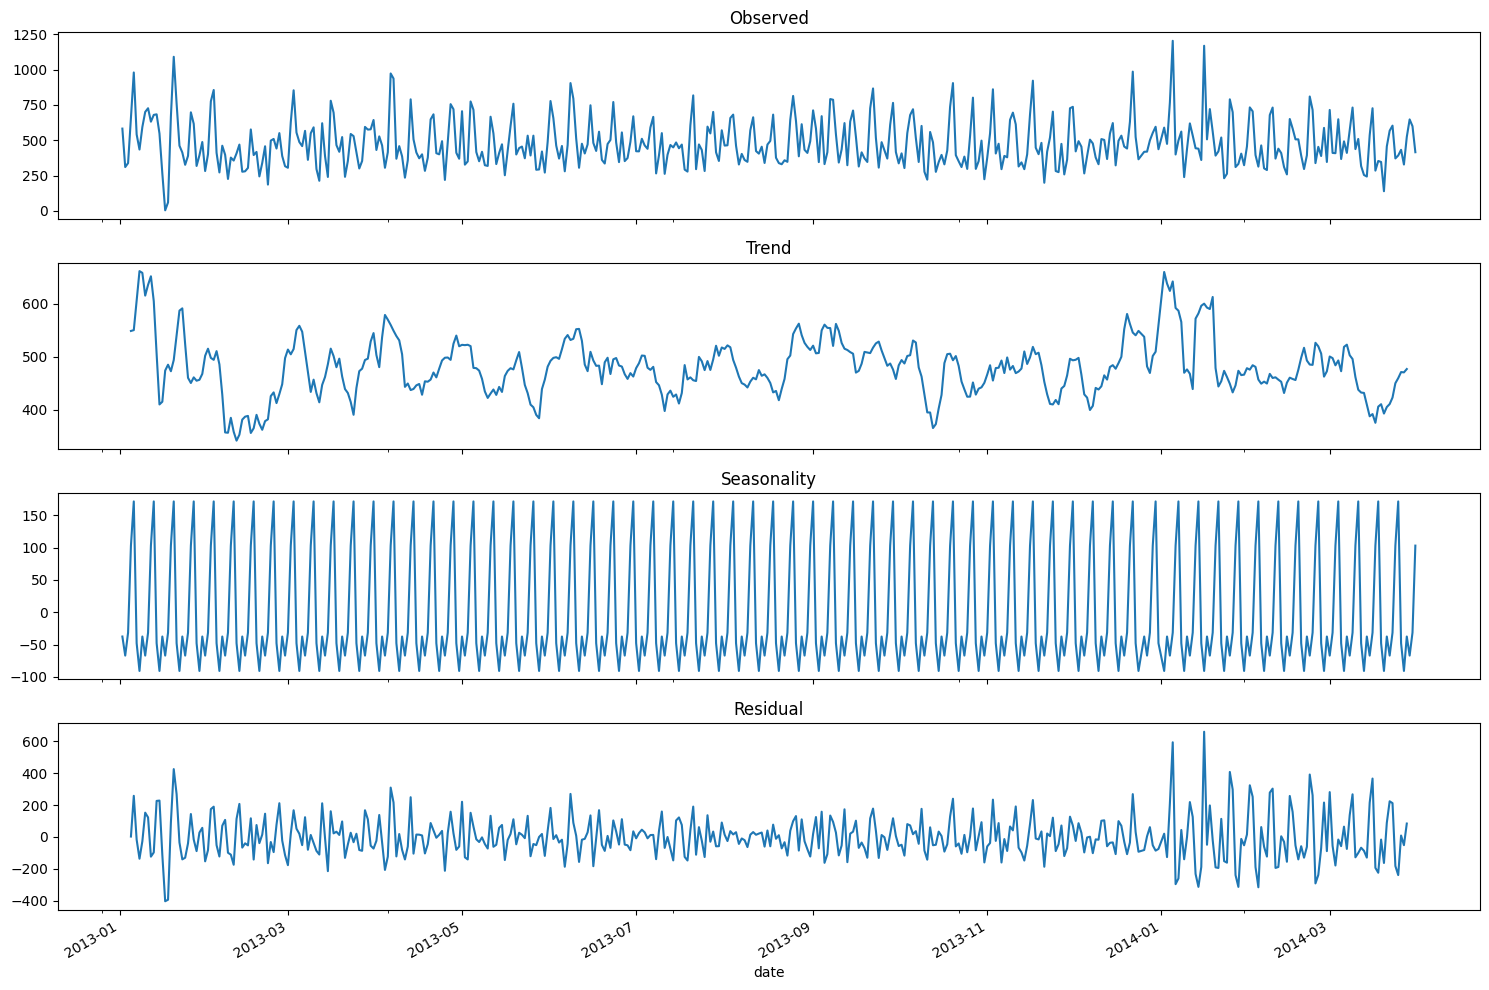

In [7]:
PERIOD = 7   # adjust as needed

decomp = seasonal_decompose(df[TARGET_COLUMN].dropna(), model='additive', period=PERIOD)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonality')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

---
## S7 - Notes & Observations
Use this cell to document findings for this dataset.

- Date range:
- Key patterns observed:
- Missing value decisions:
- Recommended period for decomposition:
- Features worth engineering: